# Frequency Estimation and Heavy Hitters
## Executive summary
### 1. Misra-Gries Algorithm
TODO:
### 2. Count-Min sketch
TODO:

### Error measure
Measuring the error over the entire universe $U$ using $\sum_{x\in U}|f(x) - \hat{f}(x)|$ presents multiple problems. First, the universe is often intractably large (e.g., $U$ containing all possible strings), making it computationally impossible to calculate the exact sum. Second, the metric disproportionately penalizes specific algorithmic behaviors:
- **Count-Min Sketch (CMS)* suffers from hash collisions, meaning every estimate is an overestimation ($\hat{f}(x) \ge f(x)$). Because Count-Min Sketch assigns non-zero estimates to millions of elements that never even appeared in the stream, summing these small, individual errors over the massive size of $U$ results in a giant aggregate error. This completely obscures how well the algorithm actually performs on the elements we care about.
- **Misra-Gries Algorithm (MG)** is designed exclusively to track up to $k$ heavy hitters, naturally discarding infrequent items. Using a global sum forces us to evaluate the algorithm on elements it was explicitly designed to ignore. Furthermore, for the elements it _does_ track, it consistently underestimates the true count because it subtracts values when space is limited.

#### Proposed Alternative
Because both algorithms are designed specifically to find heavy hitters, the evaluation should be restricted to those items. Let $\text{Top-K} \subseteq U$ be the set containing the $K$ true most frequent elements in the stream. A more appropriate measure is the Mean Absolute Error (MAE) over this subset:
$$\frac{1}{K} \sum_{x \in \text{Top-K}}|f(x) - \hat{f}(x)|$$

**Why this is better:**
The first problem is eliminated because we limit the evaluation to a small, known subset of $U$, making it computationally feasible. For the Misra-Gries algorithm, this metric perfectly captures its underestimation behavior on the exact elements it targets (assuming we match the evaluation $K$ to the algorithm's parameter $k$). For Count-Min Sketch, while the algorithm still overestimates, we are no longer aggregating the microscopic noise of millions of irrelevant, zero-frequency elements, allowing for a fair comparison of how well both methods estimate the most relevant data.






## Jupyter Notebook
### Import

In [1]:
import numpy as np
import tracemalloc
import time
import random
from collections import Counter

import plt

### Helper Functions

Below, we provide some helper functions that will be useful for this assignment.

First, we give a function for measuring the time and memory usage of function calls. To measure the time and memory usage of a function call ``myFunc(x,y,z)`` use the following code: ``measure_time_and_memory(myFunc, x, y, z)``.

In [2]:
def measure_time_and_memory(func, *args, **kwargs):
    tracemalloc.start()
    start_time = time.perf_counter()

    result = func(*args, **kwargs)

    end_time = time.perf_counter()
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    return end_time - start_time, peak / 10 ** 6, result

We also provide an implementation of the simple tabulation hash function which returns a 32-bit integer hash value.

In [3]:
def simple_tab32(H):
    return lambda x: _simple_tab32(x, H)


def _simple_tab32(x: int, H: np.ndarray) -> int:
    h = 0
    for i in range(4):
        c = x & 0xFF  # Extract the lowest 8 bits
        h ^= H[i, c]
        x >>= 8
    return h

 You can use these hash functions as follows:

In [4]:
H = np.random.randint(0, 2 ** 32, size=(4, 256), dtype=np.uint32)
myHashFunc = simple_tab32(H)
print(myHashFunc(5))
print(myHashFunc(10))

263833764
2642359232


You also find a function ``sample_zipf_like`` which allows for sampling from Zipfian distributions.

In [5]:
def sample_zipf_like(a, n, size):
    """
    Sample from a Zipf-like distribution over {1, ..., n} with exponent a.
    
    Parameters:
        a (float): Exponent (e.g., 0.5 for 1/sqrt(i))
        n (int): Maximum rank
        size (int): Number of samples to draw
        
    Returns:
        np.ndarray: Array of samples
    """
    weights = np.array([1 / (i ** a) for i in range(1, n + 1)])
    probabilities = weights / weights.sum()
    return np.random.choice(np.arange(1, n + 1), size=size, p=probabilities)

An example call is as follows:

In [6]:
a = 0.75
n = 10000
numSamples = 1000000

sample = sample_zipf_like(a, n, numSamples)

### Implementation of Frequency Estimation Data Structures

In [7]:
class DictionaryBaseline:
    def __init__(self):
        self.counters = {}

    def update(self, x, v):
        self.counters[x] = self.counters.get(x, 0) + v

    def query(self, x):
        return self.counters.get(x, 0)

In [8]:
class MisraGries:
    def __init__(self, maxNumCounters):
        # Initialize a set of counters that is initially empty
        self.counters = {}
        self.maxNumCounters = maxNumCounters

    def update(self, x, v):
        if v < 0: raise ValueError("MisraGries does not allow negative numbers")

        # if there exists a counter for x_i then
        if x in self.counters:
            # Increase the counter of x_i by v_i
            self.counters[x] += v

        else:
            # Create a new counter for x_i and initialize it with v_i
            self.counters[x] = v

            # if there are more than 1/ε counters then
            if len(self.counters) > self.maxNumCounters:
                # Find the value vmin of the smallest counter
                v_min = min(self.counters.values())

                for x_key in list(self.counters.keys()):
                    # Decrease all counters by v_min
                    self.counters[x_key] -= v_min
                    if self.counters[x_key] <= 0:
                        # Remove all counters that are 0
                        self.counters.pop(x_key)

    def query(self, x):
        # if there exists a counter for x then return the value of the counter for x else return 0
        return self.counters.get(x, 0)

In [9]:
class CountMinSketch:
    def __init__(self, numCols: int, numRows: int, hashSeed = 42):

        # numRows ~= k
        self.numRows = numRows
        # numCols ~= l
        self.numCols = numCols

        np.random.seed(hashSeed)

        # h_1, ..., h_k ← independently sample k pairwise independent hash functions mapping from U to [l]
        self.hashFunctions = []
        for _ in range(numRows): # 1, ..., k
            H = np.random.randint(0, 2 ** 32, size=(4, 256), dtype=np.uint32)
            self.hashFunctions.append(simple_tab32(H))

        # C ← an all-zeroes matrix of size k × ℓ
        self.C = np.zeros(shape=(numRows, numCols), dtype=np.int64)

    def update(self, x, v):
        if v < 0: raise ValueError("CountMinSketch does not allow negative numbers")

        for j, h_j in enumerate(self.hashFunctions): # j = 1, ..., k
            col = h_j(x) % self.numCols
            self.C[j, col] += v

    def query(self, x):
        return min(
            self.C[j, h_j(x) % self.numCols]
            for j, h_j in enumerate(self.hashFunctions) # j = 1, ..., k
        )


### Experimental Evaluation

In [10]:
def evaluate_algorithms(stream, k_top=100, mg_counters=500, cms_rows=5, cms_cols=200):
    # baseline
    baseline = DictionaryBaseline()
    for item in stream:
        baseline.update(item, 1)

    true_counts = Counter(baseline.counters)
    top_k_items = true_counts.most_common(k_top)

    # helper function for better tracking
    def run_misra_gries():
        mg = MisraGries(maxNumCounters=mg_counters)
        for item in stream:
            mg.update(item, 1)
        return mg

    def run_count_min_sketch():
        cms = CountMinSketch(numRows=cms_rows, numCols=cms_cols)
        for item in stream:
            cms.update(item, 1)
        return cms

    # misra-gries evaluation + measuring
    mg_time, mg_mem, mg = measure_time_and_memory(run_misra_gries)

    # count-min sketch evaluation + measuring
    cms_time, cms_mem, cms = measure_time_and_memory(run_count_min_sketch)

    # calculate error
    mg_error_sum = 0
    cms_error_sum = 0
    cms_errors = []

    for item, true_freq in top_k_items:
        mg_est = mg.query(item)
        cms_est = cms.query(item)

        mg_error_sum += abs(true_freq - mg_est)

        c_err = abs(true_freq - cms_est)
        cms_error_sum += c_err
        cms_errors.append(c_err)

    return {
        "mg_mae": mg_error_sum / k_top,
        "cms_mae": cms_error_sum / k_top,
        "cms_std": np.std(cms_errors),
        "mg_time": mg_time,
        "cms_time": cms_time,
        "mg_memory_mb": mg_mem,
        "cms_memory_mb": cms_mem
    }



### Skewness of the data
In this part we are testing which algorithm performs better with differently skewed data. To ensure that the evaluation is using fair parameters we let both algorithms use the space of approximately 1000. That means MG got a size of 500, since this is a map with 500 spaces and a map uses 2 spaces for each entry we get 1000. CMS got 5 rows with 200 cols that is also 1000 spaces.

We can see in the graph that CMS has a significantly lower error up to a skewness of $a<1.5$. At $a \geq 1.5$ we start to see that both algorithms perform about the same. That makes senese since if the variaty is smaller then they wont need that much space to find them. At a low skewness Misra-Gries has to decrement often what leads to a lower count and a higher error.

Started Skewness Evaluation...
0/5 Skewness: 0.25
1/5 Skewness: 0.5
2/5 Skewness: 1
3/5 Skewness: 1.5
4/5 Skewness: 2.0


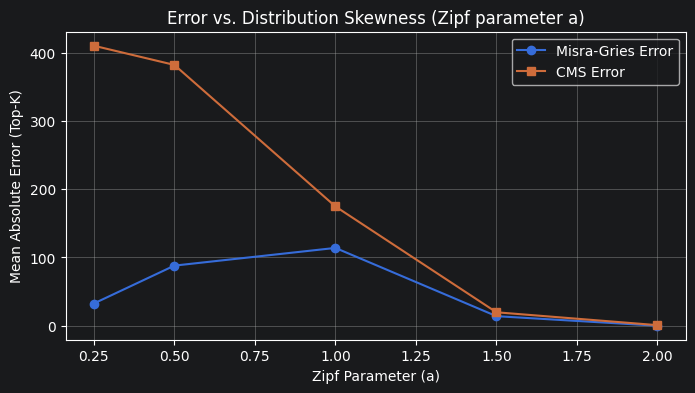

In [13]:
skews = [0.25, 0.5, 1, 1.5, 2.0]
mg_errors_skew = []
cms_errors_skew = []

print("Started Skewness Evaluation...")
for i, a in enumerate(skews):
    print(f"{i+1}/{len(skews)} Skewness: {a}")
    stream = sample_zipf_like(a, n=10000, size=100000)

    results = evaluate_algorithms(stream, mg_counters=500, cms_rows=5, cms_cols=200)
    mg_errors_skew.append(results["mg_mae"])
    cms_errors_skew.append(results["cms_mae"])

# plot (is generated by gemini)
plt.figure(figsize=(8, 4))
plt.plot(skews, mg_errors_skew, label='Misra-Gries Error', marker='o')
plt.plot(skews, cms_errors_skew, label='CMS Error', marker='s')
plt.title('Error vs. Distribution Skewness (Zipf parameter a)')
plt.xlabel('Zipf Parameter (a)')
plt.ylabel('Mean Absolute Error (Top-K)')
plt.legend()
plt.grid(True)
plt.show()

### Parameter sensitivity:
In this part im testing MG and CMS with different parameters. I chose a stream with moderately skewed distribution and tracked different metrics for evaluation. I tested different total spaces, for MG that means different number of counters (half of the total space size) and for CMS that meant different number of columns in each row.

In the results we can see that CMS gets worse in both error and standard deviation when row count count increases


In [22]:
# We keep the total space (Rows * Cols) constant at 1000, but vary Rows.
rows_to_test = [2, 4, 5, 8, 10, 20]
total_space_to_test = [200, 1000, 10000]

# Accuracy Trackers
cms_errs_rows = {ts: [] for ts in total_space_to_test}
cms_stds_rows = {ts: [] for ts in total_space_to_test}
mg_errs_space = {ts: [] for ts in total_space_to_test}

# Performance Trackers
cms_time_rows = {ts: [] for ts in total_space_to_test}
cms_mem_rows = {ts: [] for ts in total_space_to_test}
mg_time_space = {ts: [] for ts in total_space_to_test}
mg_mem_space = {ts: [] for ts in total_space_to_test}

# Using a moderately skewed distribution
stream = sample_zipf_like(1, n=10000, size=1000000)

print("Running Hyperparameter Testing...")
for i, total_space in enumerate(total_space_to_test):
    for j, r in enumerate(rows_to_test):
        current_iter = (i * len(rows_to_test)) + j + 1
        print(f"{current_iter}/{len(rows_to_test)*len(total_space_to_test)} Currently parameters: total_spaces: {total_space} rows: {r}")
        c = total_space // r
        res = evaluate_algorithms(stream, mg_counters=total_space//2, cms_rows=r, cms_cols=c)

        # Record Accuracy
        cms_errs_rows[total_space].append(res["cms_mae"])
        cms_stds_rows[total_space].append(res["cms_std"])
        mg_errs_space[total_space].append(res["mg_mae"])

        # Record Performance
        cms_time_rows[total_space].append(res["cms_time"])
        cms_mem_rows[total_space].append(res["cms_memory_mb"])
        mg_time_space[total_space].append(res["mg_time"])
        mg_mem_space[total_space].append(res["mg_memory_mb"])

Running Hyperparameter Testing...
1/18 Currently parameters: total_spaces: 200 rows: 2
2/18 Currently parameters: total_spaces: 200 rows: 4
3/18 Currently parameters: total_spaces: 200 rows: 5
4/18 Currently parameters: total_spaces: 200 rows: 8
5/18 Currently parameters: total_spaces: 200 rows: 10
6/18 Currently parameters: total_spaces: 200 rows: 20
7/18 Currently parameters: total_spaces: 1000 rows: 2
8/18 Currently parameters: total_spaces: 1000 rows: 4
9/18 Currently parameters: total_spaces: 1000 rows: 5
10/18 Currently parameters: total_spaces: 1000 rows: 8
11/18 Currently parameters: total_spaces: 1000 rows: 10
12/18 Currently parameters: total_spaces: 1000 rows: 20
13/18 Currently parameters: total_spaces: 10000 rows: 2
14/18 Currently parameters: total_spaces: 10000 rows: 4
15/18 Currently parameters: total_spaces: 10000 rows: 5
16/18 Currently parameters: total_spaces: 10000 rows: 8
17/18 Currently parameters: total_spaces: 10000 rows: 10
18/18 Currently parameters: total_sp

##### Plot the data
This part is AI generated using gemini.

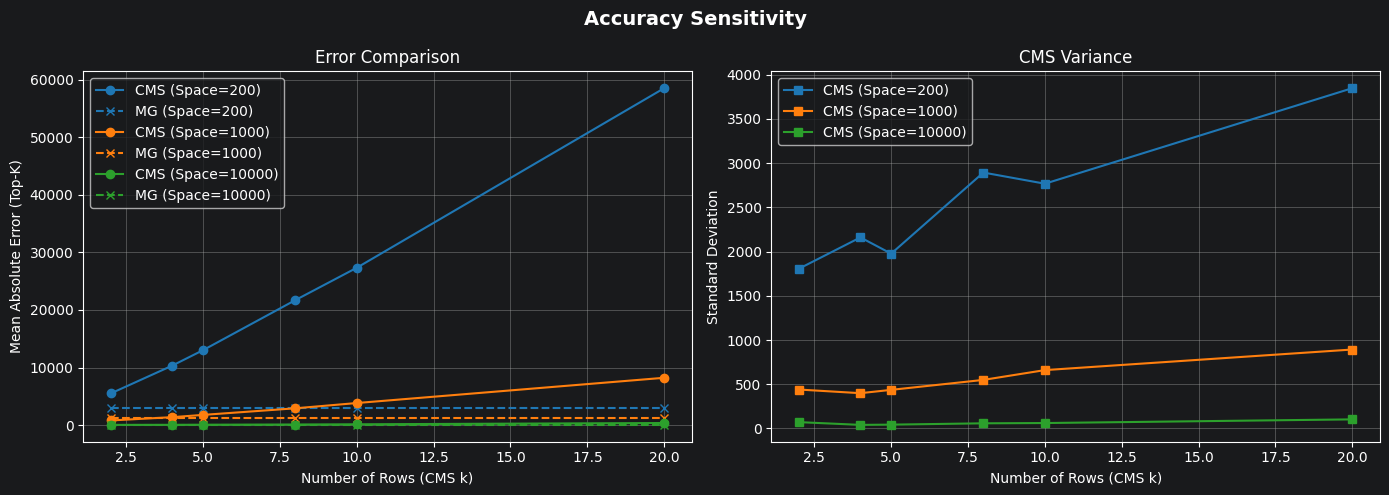

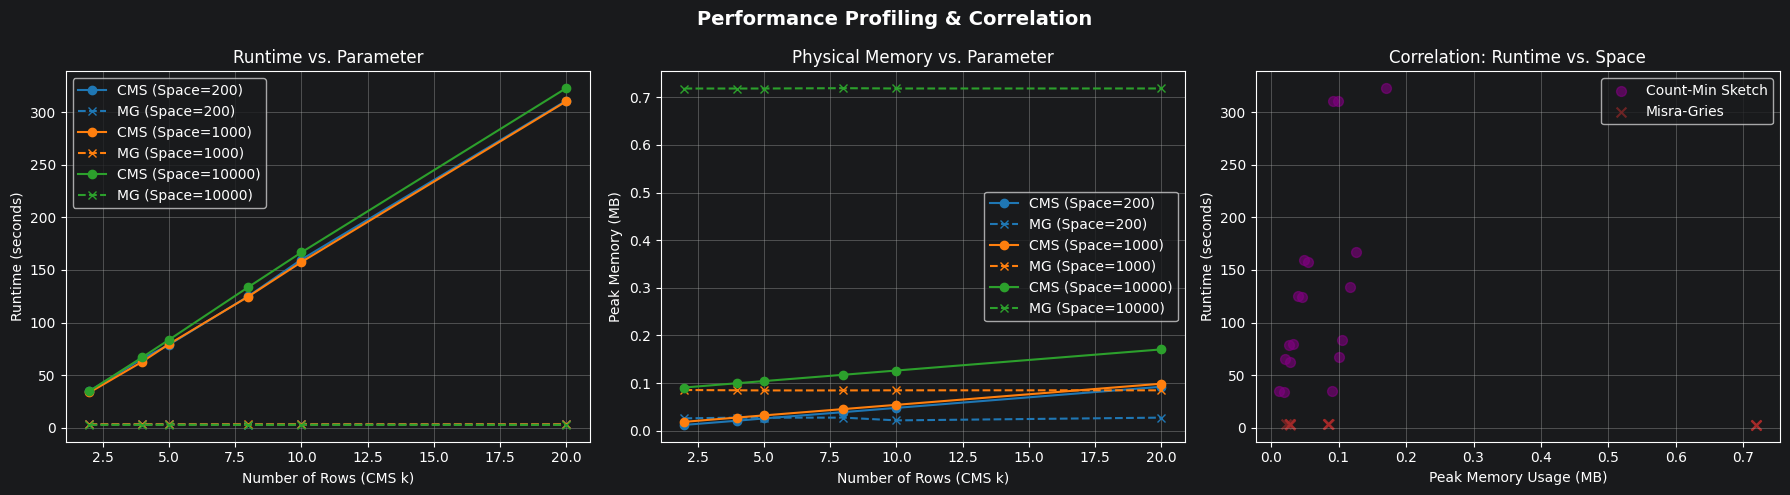

In [23]:
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for idx, ts in enumerate(total_space_to_test):
    color = colors[idx % len(colors)]
    # MAE Plot
    ax1.plot(rows_to_test, cms_errs_rows[ts], marker='o', color=color, label=f'CMS (Space={ts})')
    ax1.plot(rows_to_test, mg_errs_space[ts], marker='x', linestyle='--', color=color, label=f'MG (Space={ts})')
    # StdDev Plot
    ax2.plot(rows_to_test, cms_stds_rows[ts], marker='s', color=color, label=f'CMS (Space={ts})')

ax1.set(xlabel='Number of Rows (CMS k)', ylabel='Mean Absolute Error (Top-K)', title='Error Comparison')
ax2.set(xlabel='Number of Rows (CMS k)', ylabel='Standard Deviation', title='CMS Variance')
ax1.legend(); ax1.grid(True); ax2.legend(); ax2.grid(True)
fig1.suptitle('Accuracy Sensitivity', fontsize=14, fontweight='bold')
fig1.tight_layout()
plt.show()

# ==========================================
# FIGURE 2: PERFORMANCE & CORRELATION
# ==========================================
fig2, (ax3, ax4, ax5) = plt.subplots(1, 3, figsize=(18, 5))

# Prepare lists for the scatter plot
all_cms_time, all_cms_mem = [], []
all_mg_time, all_mg_mem = [], []

for idx, ts in enumerate(total_space_to_test):
    color = colors[idx % len(colors)]

    # Plot 3: Runtime vs Rows
    ax3.plot(rows_to_test, cms_time_rows[ts], marker='o', color=color, label=f'CMS (Space={ts})')
    ax3.plot(rows_to_test, mg_time_space[ts], marker='x', linestyle='--', color=color, label=f'MG (Space={ts})')

    # Plot 4: Memory vs Rows
    ax4.plot(rows_to_test, cms_mem_rows[ts], marker='o', color=color, label=f'CMS (Space={ts})')
    ax4.plot(rows_to_test, mg_mem_space[ts], marker='x', linestyle='--', color=color, label=f'MG (Space={ts})')

    # Accumulate data for scatter plot
    all_cms_time.extend(cms_time_rows[ts])
    all_cms_mem.extend(cms_mem_rows[ts])
    all_mg_time.extend(mg_time_space[ts])
    all_mg_mem.extend(mg_mem_space[ts])

ax3.set(xlabel='Number of Rows (CMS k)', ylabel='Runtime (seconds)', title='Runtime vs. Parameter')
ax4.set(xlabel='Number of Rows (CMS k)', ylabel='Peak Memory (MB)', title='Physical Memory vs. Parameter')
ax3.legend(); ax3.grid(True); ax4.legend(); ax4.grid(True)

# Plot 5: Correlation (Scatter Plot)
ax5.scatter(all_cms_mem, all_cms_time, color='purple', alpha=0.6, marker='o', s=50, label='Count-Min Sketch')
ax5.scatter(all_mg_mem, all_mg_time, color='brown', alpha=0.6, marker='x', s=50, label='Misra-Gries')

ax5.set(xlabel='Peak Memory Usage (MB)', ylabel='Runtime (seconds)', title='Correlation: Runtime vs. Space')
ax5.legend()
ax5.grid(True)

fig2.suptitle('Performance Profiling & Correlation', fontsize=14, fontweight='bold')
fig2.tight_layout()
plt.show()